In [154]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
 
from fair import FAIR
from fair.interface import fill, initialise
from fair.io import read_properties

# FaIR analysis of California offsetting

We're interested in understanding how the cooling affect implied by the CO2e metric compares to the actual portfolio of multi-gas emission reductions. We use FaIR to compare temperature outcomes of: 

1. gas-specific offset project emissions reductions versus the "equivalent" CO2 reductions implied by the CO2e metric
2. the offsetting program as a whole (both project fluxes and offset-justified emissions)

# Get inputs

inputs:
- ca_project_fluxes.csv
- ca_justified_offset_fluxes.csv

scenarios:
- baseline: ssp2-4.5 only
- projects_only: ssp245 + credited project fluxes (supply side; physical emissions justified by using offsets)
- emissions_only: ssp245 + offset-justified emissions (demand side; physical project co2, ch4, and cfc-12 fluxes)
- net_program: ssp245 + offset-justified emissions + project fluxes


- claimed_project: baseline + project co2 fluxes + ch4 and cfc-12 project fluxes converted to co2e
- actual_ch4: baseline + physical ch4 project fluxes only
- claimed_ch4: baseline + ch4 project fluxes converted to co2e only
- actual_cfc-12: baseline + physical cfc-12 project fluxes only
- claimed_cfc-12: baseline + cfc-12 project fluxes converted to co2e only

In [155]:
# ----------------------------
# user inputs
# ----------------------------

PROJECTS_FILE = "../timeseries-data/output-data/ca_project_fluxes.csv"
EMISSIONS_FILE = "../timeseries-data/output-data/ca_justified_emissions_fluxes.csv"
BASELINE_SCENARIO = "ssp245"

# year-dependent gwp100 for ch4
def gwp_ch4(year):
    return 21 if year <= 2020 else 25

# gwp100 for cfc-12
gwp_cfc12 = 10900

In [156]:
# ----------------------------
# load data
# ----------------------------

df_p = pd.read_csv(PROJECTS_FILE)
df_p.columns = df_p.columns.str.lower()
df_p = df_p[["year", "co2_flux", "ch4_flux", "cfc-12_flux"]].sort_values("year").fillna(0)

df_e = pd.read_csv(EMISSIONS_FILE)
df_e.columns = df_e.columns.str.lower()
df_e = df_e[["year","co2_justified","ch4_justified", "n2o_justified"]].sort_values("year").fillna(0)

# Run FaIR simulations

In [157]:
# ----------------------------
# set up fair
# ----------------------------

import contextlib
import os

f = FAIR()
f.define_time(1750, 2200, 1)
f.define_scenarios([
    BASELINE_SCENARIO,
    "emissions_only",
    "projects_only",
    "net_program",
    "claimed_project",
    "actual_ch4",
    "claimed_ch4",
    "actual_cfc12",
    "claimed_cfc12"
])
f.define_configs(["central"])

all_species, all_props = read_properties()

species = ["CO2 FFI", "CO2 AFOLU", "CH4", "N2O", "CFC-12", "CO2"]
properties = {s: all_props[s] for s in species}

properties["CO2 FFI"]["input_mode"] = "emissions"
properties["CO2 FFI"]["greenhouse_gas"] = False

properties["CO2 AFOLU"]["input_mode"] = "emissions"
properties["CO2 AFOLU"]["greenhouse_gas"] = False

properties["CH4"]["input_mode"] = "emissions"
properties["CH4"]["greenhouse_gas"] = True

properties["N2O"]["input_mode"] = "emissions"
properties["N2O"]["greenhouse_gas"] = True

properties["CFC-12"]["input_mode"] = "emissions"
properties["CFC-12"]["greenhouse_gas"] = True

properties["CO2"]["input_mode"] = "calculated"
properties["CO2"]["greenhouse_gas"] = True

f.define_species(species, properties)
f.allocate()
f.fill_species_configs()

# TK: what's the provenance of these configs? 

fill(f.climate_configs["ocean_heat_capacity"], [8.0, 14.0, 100.0], config="central")
fill(f.climate_configs["ocean_heat_transfer"], [1.1, 1.6, 0.9], config="central")
fill(f.climate_configs["deep_ocean_efficacy"], 1.1, config="central")

In [158]:
# ----------------------------
# load baseline emissions
# ----------------------------

backup = list(f.scenarios)
f.scenarios = [BASELINE_SCENARIO]
f.fill_from_rcmip()
f.scenarios = backup

for sp in ["CO2 FFI", "CO2 AFOLU", "CH4", "N2O", "CFC-12"]:
    base = f.emissions.sel(
        scenario=BASELINE_SCENARIO,
        config="central",
        specie=sp
    ).values

    for scen in ["emissions_only","projects_only","net_program", "claimed_project", "actual_ch4", "claimed_ch4", "actual_cfc12", "claimed_cfc12"]:
        fill(f.emissions, base, scenario=scen, config="central", specie=sp)

In [159]:
# ----------------------------
# apply project perturbations
# ----------------------------

timepoints = np.asarray(f.timepoints, dtype=float)

for _, row in df_p.iterrows():

    year = float(row["year"])
    i = np.argmin(np.abs(timepoints - year))
    yr = timepoints[i]

    # convert units
    co2_p = row["co2_flux"] / 1e9       # Conversion from ton to gigaton
    ch4_p = row["ch4_flux"] / 1e6       # Conversion from ton to megaton
    cfc12_p = row["cfc-12_flux"] / 1e3  # Conversion from ton to kilaton

    # projects_only + net program: all project fluxes enter as physical gases
    for scen in ["projects_only", "net_program"]:
        f.emissions.loc[dict(timepoints=yr, scenario=scen, config="central", specie="CO2 FFI")].values += co2_p
        f.emissions.loc[dict(timepoints=yr, scenario=scen, config="central", specie="CH4")].values += ch4_p
        f.emissions.loc[dict(timepoints=yr, scenario=scen, config="central", specie="CFC-12")].values += cfc12_p

    # claimed_project: co2 project fluxes + ch4 and cfc12 project fluxes represented as co2-equivalent
    f.emissions.loc[dict(timepoints=yr, scenario="claimed_project", config="central", specie="CO2 FFI")].values += co2_p + ch4_p * gwp_ch4(year) / 1000 + cfc12_p * gwp_cfc12 / 1e6

    # actual_ch4: only physical ch4 project flux
    f.emissions.loc[dict(timepoints=yr, scenario="actual_ch4", config="central", specie="CH4")].values += ch4_p

    # claimed_ch4: only ch4 project flux represented as co2-equivalent
    f.emissions.loc[dict(timepoints=yr, scenario="claimed_ch4", config="central", specie="CO2 FFI")].values += ch4_p * gwp_ch4(year) / 1000

    # actual_cfc12: only physical cfc-12 project flux
    f.emissions.loc[dict(timepoints=yr, scenario="actual_cfc12", config="central", specie="CFC-12")].values += cfc12_p

    # claimed_cfc12: only cfc-12 flux represented as co2-equivalent
    f.emissions.loc[dict(timepoints=yr, scenario="claimed_cfc12", config="central", specie="CO2 FFI")].values += cfc12_p * gwp_cfc12 / 1e6

In [160]:
# ----------------------------
# apply offset-justified emissions
# ----------------------------

for _, row in df_e.iterrows():

    year = float(row["year"])
    i = np.argmin(np.abs(timepoints - year))
    yr = timepoints[i]

    co2_e = row["co2_justified"] / 1e9
    ch4_e = row["ch4_justified"] / 1e6
    n2o_e = row["n2o_justified"] / 1e6

    # emissions_only + net program: all justified emissions fluxes enter as physical gases
    for scen in ["emissions_only", "net_program"]:
        f.emissions.loc[dict(timepoints=yr, scenario=scen, config="central", specie="CO2 FFI")].values += co2_e
        f.emissions.loc[dict(timepoints=yr, scenario=scen, config="central", specie="CH4")].values += ch4_e
        f.emissions.loc[dict(timepoints=yr, scenario=scen, config="central", specie="N2O")].values += n2o_e


In [161]:
# ----------------------------
# initialise + run
# ----------------------------

initialise(f.concentration, 278.0, specie="CO2")
initialise(f.concentration, 730.0, specie="CH4")
initialise(f.concentration, 270.0, specie="N2O")
initialise(f.concentration, 0.0, specie="CFC-12")

initialise(f.forcing, 0.0)
initialise(f.temperature, 0.0)
initialise(f.cumulative_emissions, 0.0)
initialise(f.airborne_emissions, 0.0)
initialise(f.ocean_heat_content_change, 0.0)

f.run()

Running 9 projections in parallel: 100%|████████████████████████████████████████████████████████████████| 450/450 [00:00<00:00, 5498.19timesteps/s]


# Exploring program temp impact

As a starting point, we can explore how the cooling affect of the project fluxes and the warming affect of justified emissions combine into a program-wide temperature impact

In [162]:
# ----------------------------
# extract temperature trajectories
# ----------------------------

years = np.asarray(f.timebounds, dtype=float)
baseline = f.temperature.loc[dict(scenario=BASELINE_SCENARIO, config="central", layer=0)]
emissions_only = f.temperature.loc[dict(scenario="emissions_only", config="central", layer=0)]
projects_only = f.temperature.loc[dict(scenario="projects_only", config="central", layer=0)]
net_program = f.temperature.loc[dict(scenario="net_program", config="central", layer=0)]


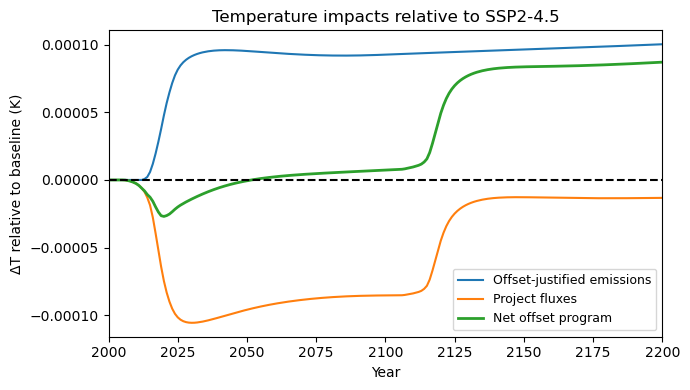

In [163]:
plt.figure(figsize=(7,4))

plt.plot(years, emissions_only - baseline, label="Offset-justified emissions")
plt.plot(years, projects_only - baseline, label="Project fluxes")
plt.plot(years, net_program - baseline, label="Net offset program", linewidth=2)

plt.axhline(0, ls="--", color="k")
plt.xlim(2000,2200)
plt.xlabel("Year")
plt.ylabel("ΔT relative to baseline (K)")
plt.title("Temperature impacts relative to SSP2-4.5")
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

We can also determine in which years in which the program as a whole begins provide more or less of a cooling effect than implied by the co2e equivalent offsetting logic — i.e. "crossover years". (Note, this is a picture of the program activity to date and it's impact over time with no assumptions about ongoing or future activity.)

In [164]:
diff = net_program - baseline
crossover_years = years[:-1][np.diff(np.sign(diff)) != 0]
print(crossover_years.astype(int))

[2004 2051]


It's striking that the program as a whole becomes net warming by 2053. This could driven by a number of factors including: 

1. the composition of justified emissions (what's different if all justified emissions are co2?)
2. the gwp100 conversion (what's the temperature trajectory difference between each constituent project flux gas and the "equivalent" quantity of co2 reductions?) 
3. the choice of equivalency metric (what would have been different if gwp20, gtp50, gtp100, or like-for-like logic had been applied instead of gwp100?) 

We'll explore each in turn. 

## 01 — impact of justified emissions composition

## 02 — impact of the gwp100 conversion

In [165]:
# extract temperature trajectories
years = np.asarray(f.timebounds, dtype=float)

baseline = f.temperature.loc[dict(scenario=BASELINE_SCENARIO, config="central", layer=0)]
actual = f.temperature.loc[dict(scenario="projects_only", config="central", layer=0)]
claimed = f.temperature.loc[dict(scenario="claimed_project", config="central", layer=0)]
actual_ch4_t = f.temperature.loc[dict(scenario="actual_ch4", config="central", layer=0)]
claimed_ch4_t = f.temperature.loc[dict(scenario="claimed_ch4", config="central", layer=0)]
actual_cfc12_t = f.temperature.loc[dict(scenario="actual_cfc12", config="central", layer=0)]
claimed_cfc12_t = f.temperature.loc[dict(scenario="claimed_cfc12", config="central", layer=0)]

In [166]:
# extract emissions data 

years_e = np.asarray(f.timepoints, dtype=float)

baseline_co2   = f.emissions.loc[dict(scenario=BASELINE_SCENARIO, config="central", specie="CO2 FFI")]
baseline_ch4   = f.emissions.loc[dict(scenario=BASELINE_SCENARIO, config="central", specie="CH4")]
baseline_cfc12 = f.emissions.loc[dict(scenario=BASELINE_SCENARIO, config="central", specie="CFC-12")]
actual_co2_emis = f.emissions.loc[dict(scenario="projects_only", config="central", specie="CO2 FFI")]

actual_ch4_emis        = f.emissions.loc[dict(scenario="projects_only", config="central", specie="CH4")]
actual_cfc12_emis      = f.emissions.loc[dict(scenario="projects_only", config="central", specie="CFC-12")]

actual_co2_only_emis   = f.emissions.loc[dict(scenario="projects_only", config="central", specie="CO2 FFI")]
actual_ch4_only_emis   = f.emissions.loc[dict(scenario="actual_ch4", config="central", specie="CH4")]
actual_cfc12_only_emis = f.emissions.loc[dict(scenario="actual_cfc12", config="central", specie="CFC-12")]

claimed_co2_only_co2   = f.emissions.loc[dict(scenario="claimed_project", config="central", specie="CO2 FFI")]
claimed_ch4_only_co2   = f.emissions.loc[dict(scenario="claimed_ch4", config="central", specie="CO2 FFI")]
claimed_cfc12_only_co2 = f.emissions.loc[dict(scenario="claimed_cfc12", config="central", specie="CO2 FFI")]

As a starting point, we can compare the cooling affect of the actual portfolio of offset project fluxes versus the claimed cooling effect of an "equivalent" CO2 flux.

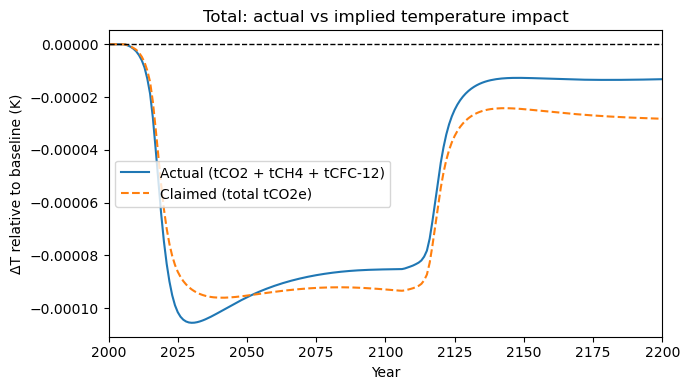

In [167]:
plt.figure(figsize=(7, 4))
plt.plot(years, projects_only - baseline,  label="Actual (tCO2 + tCH4 + tCFC-12)")
plt.plot(years, claimed - baseline, "--", label="Claimed (total tCO2e)")
plt.axhline(0, linestyle="--", linewidth=1, color='k')
plt.xlim(2000, 2200)
plt.xlabel("Year")
plt.ylabel("ΔT relative to baseline (K)")
plt.title("Total: actual vs implied temperature impact")
plt.legend()
plt.tight_layout()
plt.show()

In [168]:
diff = actual - claimed
crossover_years = years[:-1][np.diff(np.sign(diff)) != 0]
print(crossover_years.astype(int))

[2005 2051]


We can explore what underpins the early cooling to long-term warming trend by examining ch4 and cfc-12 individually. 

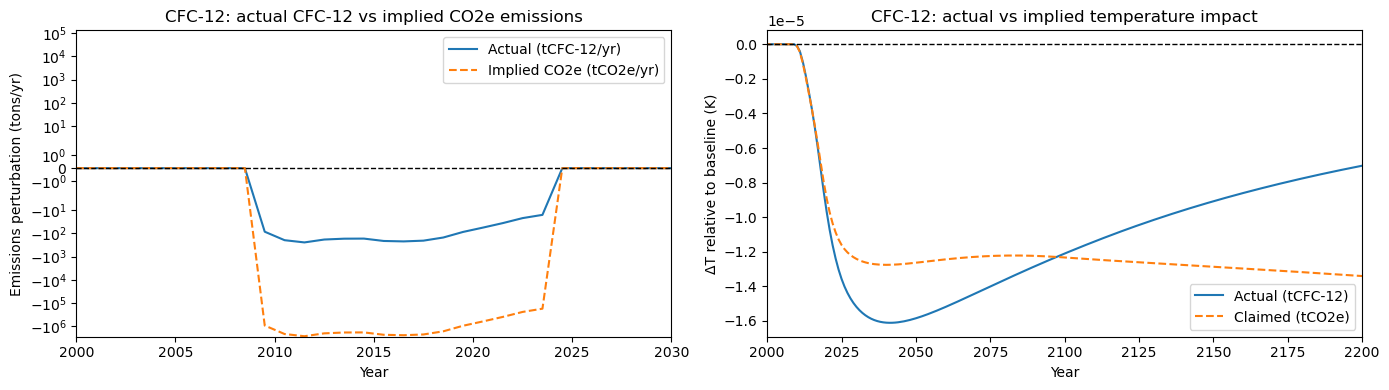

[2015 2097]


In [170]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# --- CFC-12 emissions: actual vs implied CO2e flux ---
ax1.plot(years_e, (actual_cfc12_only_emis - baseline_cfc12) * 1e3,      label="Actual (tCFC-12/yr)")
ax1.plot(years_e, (claimed_cfc12_only_co2 - baseline_co2) * 1e9, "--", label="Implied CO2e (tCO2e/yr)")
ax1.axhline(0, linestyle="--", linewidth=1, color='k')
ax1.set_xlim(2000, 2030)
ax1.set_yscale("symlog")
ax1.set_xlabel("Year")
ax1.set_ylabel("Emissions perturbation (tons/yr)")
ax1.set_title("CFC-12: actual CFC-12 vs implied CO2e emissions")
ax1.legend()

# --- CFC-12 component temperature: actual vs claimed ---
ax2.plot(years, actual_cfc12_t  - baseline, label="Actual (tCFC-12)")
ax2.plot(years, claimed_cfc12_t - baseline, "--", label="Claimed (tCO2e)")
ax2.axhline(0, linestyle="--", linewidth=1, color='k')
ax2.set_xlim(2000, 2200)
ax2.set_xlabel("Year")
ax2.set_ylabel("ΔT relative to baseline (K)")
ax2.set_title("CFC-12: actual vs implied temperature impact")
ax2.legend()

plt.tight_layout()
plt.show()

# --- determine crossover years ---
diff = (actual_cfc12_t  - baseline) - (claimed_cfc12_t - baseline)
crossover_years = years[:-1][np.diff(np.sign(diff)) != 0]
crossover_years = crossover_years[crossover_years > 2010]
print(crossover_years.astype(int))

## 03 — Impact of the equivalency metric choice

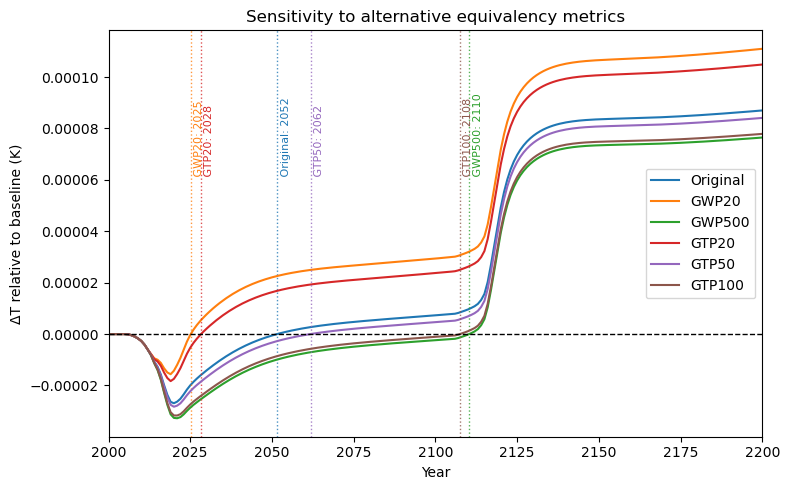

In [171]:
# Assume that all change in credits generated by using different equivalncey metrics is countered by a change in justified CO2 emissions
# Justified CH4 and N2O emissions RTS between scenarios because they make up <1% of total justified CO2e.

equiv_metrics = {
    "GWP20":  {"ch4": 84, "cfc-12": 10800},
    "GWP500": {"ch4": 8,  "cfc-12": 5200},
    "GTP20":  {"ch4": 67, "cfc-12": 11300},
    "GTP50": {"ch4": 14, "cfc-12": 11000},
    "GTP100": {"ch4": 4,  "cfc-12": 8450},}

def make_alt_justified_emissions(df_p, df_e, metric_values):
    df_alt = df_e.copy()

    # calculate original co2e using current program gwp100 assumptions
    project_co2e = df_p[["year", "ch4_flux", "cfc-12_flux"]].copy()
    project_co2e["original_ch4_co2e"] = (project_co2e["ch4_flux"] * project_co2e["year"].apply(gwp_ch4))
    project_co2e["original_cfc12_co2e"] = (project_co2e["cfc-12_flux"] * gwp_cfc12)

    # calculate alternative co2e using selected metric
    project_co2e["alt_ch4_co2e"] = (project_co2e["ch4_flux"] * metric_values["ch4"])
    project_co2e["alt_cfc12_co2e"] = (project_co2e["cfc-12_flux"] * metric_values["cfc-12"])

    # difference in credited co2e relative to current accounting
    project_co2e["delta_co2e"] = (project_co2e["alt_ch4_co2e"] + project_co2e["alt_cfc12_co2e"] - project_co2e["original_ch4_co2e"] - project_co2e["original_cfc12_co2e"])

    delta_by_year = (project_co2e.groupby("year")["delta_co2e"].sum().reset_index())

    # subtract the crediting difference from co2 justified emissions
    df_alt = df_alt.merge(delta_by_year, on="year", how="left")
    df_alt["delta_co2e"] = df_alt["delta_co2e"].fillna(0)
    df_alt["co2_justified"] = df_alt["co2_justified"] - df_alt["delta_co2e"]

    return df_alt.drop(columns="delta_co2e")


def run_program_fair(df_p, df_e_run):
    f_run = FAIR()
    f_run.define_time(1750, 2200, 1)
    f_run.define_scenarios([BASELINE_SCENARIO, "net_program"])
    f_run.define_configs(["central"])

    all_species, all_props = read_properties()

    species = ["CO2 FFI", "CO2 AFOLU", "CH4", "N2O", "CFC-12", "CO2"]
    properties = {s: all_props[s] for s in species}

    properties["CO2 FFI"]["input_mode"] = "emissions"
    properties["CO2 FFI"]["greenhouse_gas"] = False
    properties["CO2 AFOLU"]["input_mode"] = "emissions"
    properties["CO2 AFOLU"]["greenhouse_gas"] = False
    properties["CH4"]["input_mode"] = "emissions"
    properties["CH4"]["greenhouse_gas"] = True
    properties["N2O"]["input_mode"] = "emissions"
    properties["N2O"]["greenhouse_gas"] = True
    properties["CFC-12"]["input_mode"] = "emissions"
    properties["CFC-12"]["greenhouse_gas"] = True
    properties["CO2"]["input_mode"] = "calculated"
    properties["CO2"]["greenhouse_gas"] = True

    f_run.define_species(species, properties)
    f_run.allocate()
    f_run.fill_species_configs()

    fill(f_run.climate_configs["ocean_heat_capacity"], [8.0, 14.0, 100.0], config="central")
    fill(f_run.climate_configs["ocean_heat_transfer"], [1.1, 1.6, 0.9], config="central")
    fill(f_run.climate_configs["deep_ocean_efficacy"], 1.1, config="central")

    backup = list(f_run.scenarios)
    f_run.scenarios = [BASELINE_SCENARIO]
    f_run.fill_from_rcmip()
    f_run.scenarios = backup

    for sp in ["CO2 FFI", "CO2 AFOLU", "CH4", "N2O", "CFC-12"]:
        base = f_run.emissions.sel(scenario=BASELINE_SCENARIO, config="central", specie=sp).values

        fill(f_run.emissions, base, scenario="net_program", config="central", specie=sp)

    timepoints = np.asarray(f_run.timepoints, dtype=float)

    # project fluxes
    for _, row in df_p.iterrows():
        yr = timepoints[np.argmin(np.abs(timepoints - float(row["year"])))]

        f_run.emissions.loc[dict(timepoints=yr, scenario="net_program", config="central", specie="CO2 FFI")].values += row["co2_flux"] / 1e9
        f_run.emissions.loc[dict(timepoints=yr, scenario="net_program", config="central", specie="CH4")].values += row["ch4_flux"] / 1e6
        f_run.emissions.loc[dict(timepoints=yr, scenario="net_program", config="central", specie="CFC-12")].values += row["cfc-12_flux"] / 1e3

    # justified emissions
    for _, row in df_e_run.iterrows():
        yr = timepoints[np.argmin(np.abs(timepoints - float(row["year"])))]

        f_run.emissions.loc[dict(timepoints=yr, scenario="net_program", config="central", specie="CO2 FFI")].values += row["co2_justified"] / 1e9
        f_run.emissions.loc[dict(timepoints=yr, scenario="net_program", config="central", specie="CH4")].values += row["ch4_justified"] / 1e6

        if "n2o_justified" in df_e_run.columns:
            f_run.emissions.loc[dict(timepoints=yr, scenario="net_program", config="central", specie="N2O")].values += row["n2o_justified"] / 1e6

    initialise(f_run.concentration, 278.0, specie="CO2")
    initialise(f_run.concentration, 730.0, specie="CH4")
    initialise(f_run.concentration, 270.0, specie="N2O")
    initialise(f_run.concentration, 0.0, specie="CFC-12")

    initialise(f_run.forcing, 0.0)
    initialise(f_run.temperature, 0.0)
    initialise(f_run.cumulative_emissions, 0.0)
    initialise(f_run.airborne_emissions, 0.0)
    initialise(f_run.ocean_heat_content_change, 0.0)

    with open(os.devnull, "w") as fnull:
        with contextlib.redirect_stdout(fnull), contextlib.redirect_stderr(fnull):
            f_run.run()

    years_run = np.asarray(f_run.timebounds, dtype=float)

    baseline_temp = f_run.temperature.loc[dict(scenario=BASELINE_SCENARIO, config="central", layer=0)].values

    net_temp = f_run.temperature.loc[dict(scenario="net_program", config="central", layer=0)].values

    return years_run, net_temp - baseline_temp


# run original and alternative metric cases
temp_results = {}

years_sens, temp_results["Original"] = run_program_fair(df_p, df_e)

for metric_name, metric_values in equiv_metrics.items():
    df_e_alt = make_alt_justified_emissions(df_p, df_e, metric_values)
    _, temp_results[metric_name] = run_program_fair(df_p, df_e_alt)


#  ---  helper: find crossover year  --- 

def find_crossover_year(years, temp):
    years = np.asarray(years)
    temp = np.asarray(temp)

    # find first transition from negative to non-negative
    idx = np.where((temp[:-1] < 0) & (temp[1:] >= 0))[0]

    if len(idx) == 0:
        return np.nan

    i = idx[0]

    # linearly interpolate between the two surrounding points
    x0, x1 = years[i], years[i + 1]
    y0, y1 = temp[i], temp[i + 1]

    return x0 + (0 - y0) * (x1 - x0) / (y1 - y0)


#  ---  plot temperature trajectories with crossover years  --- 

plt.figure(figsize=(8, 5))
ax = plt.gca()

for label, temp in temp_results.items():
    line, = ax.plot(years_sens, temp, label=label)
    color = line.get_color()

    crossover_year = find_crossover_year(years_sens, temp)

    if not np.isnan(crossover_year):
        ax.axvline(crossover_year, linestyle=":", linewidth=1, color=color, alpha=0.8)

        ax.text(crossover_year+1, 0.00006, f" {label}: {crossover_year:.0f}", color=color, rotation=90, va="bottom", ha="left", fontsize=8)

ax.axhline(0, linestyle="--", linewidth=1, color="k")
ax.set_xlim(2000, 2200)
ax.set_xlabel("Year")
ax.set_ylabel("ΔT relative to baseline (K)")
ax.set_title("Sensitivity to alternative equivalency metrics")
ax.legend()
plt.tight_layout()
plt.show()

As expected, using more conservative GWP/GTP metrics results in a more delayed crossover point. GWP500 and GTP200 start to butt up against the temperature impact of released temporary CO2 storage. 

Maybe we should run the model forward assuming no stored CO2 is released so it's easier to asses the temperature impact of SLCP crediting.

,Metric,CH4 metric,CFC-12 metric,Crossover year,Justified CO2e from non-CO2 project fluxes (MtCO2e)
0,Original,current gwp100,10900,2051.6,38.27
1,GWP20,84,10800,2025.2,84.28
2,GWP500,8,5200,2110.4,16.53
3,GTP20,67,11300,2028.3,72.70
4,GTP50,14,11000,2061.9,32.79
5,GTP100,4,8450,2107.6,20.18


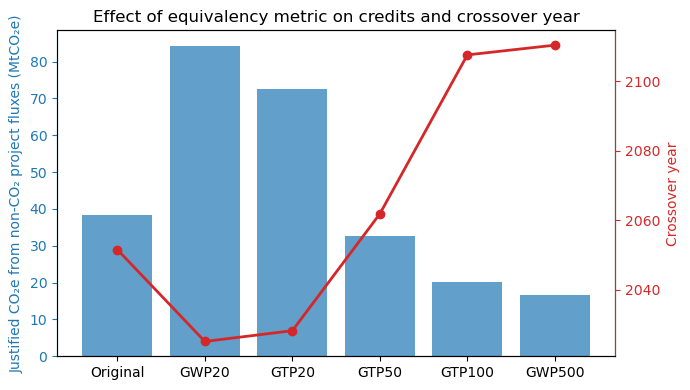

In [192]:
# ---- summarize equivalency metric results ----

equiv_summary = []

# original program accounting
original_crossover = find_crossover_year(years_sens, temp_results["Original"])

original_nonco2_justified = -1 * ((df_p["ch4_flux"] * df_p["year"].apply(gwp_ch4)) + (df_p["cfc-12_flux"] * gwp_cfc12)).sum()

equiv_summary.append({
    "metric": "Original",
    "ch4_metric": "current gwp100",
    "cfc12_metric": gwp_cfc12,
    "crossover_year": original_crossover,
    "nonco2_generated_justified_co2e": original_nonco2_justified})

# alternative metric accounting
for metric_name, metric_values in equiv_metrics.items():
    crossover_year = find_crossover_year(years_sens, temp_results[metric_name])
    nonco2_justified = -1 * ((df_p["ch4_flux"] * metric_values["ch4"]) + (df_p["cfc-12_flux"] * metric_values["cfc-12"])).sum()
    equiv_summary.append({
        "metric": metric_name,
        "ch4_metric": metric_values["ch4"],
        "cfc12_metric": metric_values["cfc-12"],
        "crossover_year": crossover_year,
        "nonco2_generated_justified_co2e": nonco2_justified})

equiv_summary = pd.DataFrame(equiv_summary)
equiv_summary["crossover_year"] = equiv_summary["crossover_year"].round(1)
equiv_summary["nonco2_generated_justified_co2e_million"] = (
    equiv_summary["nonco2_generated_justified_co2e"] / 1e6).round(2)

display(
    equiv_summary[
        ["metric", "ch4_metric", "cfc12_metric", "crossover_year", "nonco2_generated_justified_co2e_million"]
    ].rename(columns={
        "metric": "Metric",
        "ch4_metric": "CH4 metric",
        "cfc12_metric": "CFC-12 metric",
        "crossover_year": "Crossover year",
        "nonco2_generated_justified_co2e_million": "Justified CO2e from non-CO2 project fluxes (MtCO2e)"}))

# ---- credits vs crossover year ----

plot_order = ["Original", "GWP20", "GTP20", "GTP50", "GTP100", "GWP500"]
plot_df = equiv_summary.set_index("metric").loc[plot_order].reset_index()

fig, ax1 = plt.subplots(figsize=(7, 4))
x = np.arange(len(plot_df))

# left axis: credits
bars = ax1.bar(x, plot_df["nonco2_generated_justified_co2e_million"], color="tab:blue", alpha=0.7, label="Justified CO₂e")
ax1.set_ylabel("Justified CO₂e from non-CO₂ project fluxes (MtCO₂e)", color="tab:blue")
ax1.tick_params(axis="y", colors="tab:blue")
ax1.spines["left"].set_color("tab:blue")
ax1.set_xticks(x)
ax1.set_xticklabels(plot_df["metric"])

# right axis: crossover year
ax2 = ax1.twinx()

ax2.plot(x, plot_df["crossover_year"], marker="o", linewidth=2, color="tab:red", label="Crossover year")
ax2.set_ylabel("Crossover year", color="tab:red")
ax2.tick_params(axis="y", colors="tab:red")
ax2.spines["right"].set_color("tab:red")

# combined legend
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.set_title("Effect of equivalency metric on credits and crossover year")

plt.tight_layout()
plt.show()

## 04 - Effect of Program Continuation

2010-2024 average CO2 project flux (tCO2/yr): -8304093.866666666
2010-2024 average CH4 project flux (tCH4/yr): -46898.80926984127
2010-2024 average CFC-12 project flux (tCFC-12/yr): -135.84150458715595
2010-2024 average total CO2e credits (tCO2e/yr): 10957236.498412699


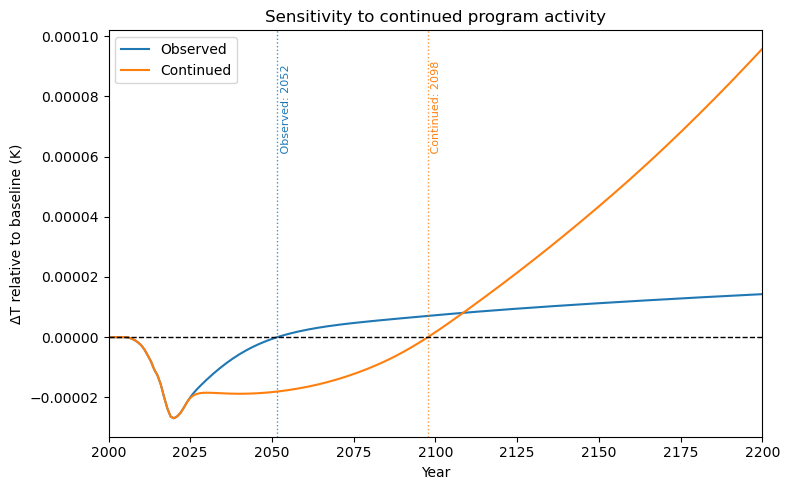

In [185]:
# In this test, the 2010 - 2024 average CH4, CFC12 and Co2 project fluxes and corresponging jsutified CO2 emissions are calculated using 
# CH4 and CFC12 GWP100 (25 and 109000, respectively), then assume those project and justified fluxes continue for 200 years.
# The release of temporary CO2 storage is ignored to assess SLCP temperature evolution. 

extension_start = 2025
extension_end = 2200

avg_window_start = 2010
avg_window_end = 2024

# ignore forest re-release rows after 2025
df_p_observed = df_p[df_p["year"] <= 2025].copy()

# calculate average annual project fluxes from 2010-2024
avg_project_fluxes = df_p_observed[
    (df_p_observed["year"] >= avg_window_start) &
    (df_p_observed["year"] <= avg_window_end)
][["co2_flux", "ch4_flux", "cfc-12_flux"]].mean()

avg_co2_flux = avg_project_fluxes["co2_flux"]
avg_ch4_flux = avg_project_fluxes["ch4_flux"]
avg_cfc12_flux = avg_project_fluxes["cfc-12_flux"]

# convert average annual project fluxes to total co2e credits
avg_co2e_credits = -1 * (
    avg_co2_flux +
    avg_ch4_flux * 25 +
    avg_cfc12_flux * 10900)

print("2010-2024 average CO2 project flux (tCO2/yr):", avg_co2_flux)
print("2010-2024 average CH4 project flux (tCH4/yr):", avg_ch4_flux)
print("2010-2024 average CFC-12 project flux (tCFC-12/yr):", avg_cfc12_flux)
print("2010-2024 average total CO2e credits (tCO2e/yr):", avg_co2e_credits)

# create extension rows
extension_years = np.arange(extension_start, extension_end + 1)

df_p_extension = pd.DataFrame({
    "year": extension_years,
    "co2_flux": avg_co2_flux,
    "ch4_flux": avg_ch4_flux,
    "cfc-12_flux": avg_cfc12_flux})

df_e_extension = pd.DataFrame({
    "year": extension_years,
    "co2_justified": avg_co2e_credits,
    "ch4_justified": 0,
    "n2o_justified": 0})

# combine observed and extended timeseries
df_p_continued = pd.concat([df_p_observed[df_p_observed["year"] < extension_start], df_p_extension], ignore_index=True).sort_values("year")

df_e_continued = pd.concat([df_e[df_e["year"] < extension_start], df_e_extension], ignore_index=True).sort_values("year")

# run observed and continued-program cases
years_observed, temp_observed = run_program_fair(df_p_observed, df_e)
years_continued, temp_continued = run_program_fair(df_p_continued, df_e_continued)


#  --- plot with crossover years  --- 

continued_results = {
    "Observed": temp_observed,
    "Continued": temp_continued}

plt.figure(figsize=(8, 5))
ax = plt.gca()

for label, temp in continued_results.items():
    line, = ax.plot(years_observed, temp, label=label)
    color = line.get_color()

    crossover_year = find_crossover_year(years_observed, temp)

    if not np.isnan(crossover_year):
        ax.axvline(crossover_year, linestyle=":", linewidth=1, color=color, alpha=0.8)
        ax.text(crossover_year+1, 0.00006, f" {label}: {crossover_year:.0f}", color=color, rotation=90, va="bottom", ha="left", fontsize=8)

ax.axhline(0, linestyle="--", linewidth=1, color="k")
ax.set_xlim(2000, 2200)
ax.set_xlabel("Year")
ax.set_ylabel("ΔT relative to baseline (K)")
ax.set_title("Sensitivity to continued program activity")
ax.legend()
plt.tight_layout()
plt.show()


This is an important result and illustrates warming stock vs cooling flow nicely. It shows that even if the CARB kept up it's CH4-CFC12-CO2 credit ratio for 200 years, the program still has a crossover point before 2100. Note that the rate of warming also accelarates the longer you justify longterm CO2 emissions with shorterm SLCP reduction.

## 05 - Effect of Non-Additionality

Gas: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:25<00:00,  8.62s/it]

Total CO2 credits: 128982213.0
Total CH4 credits: 16061514.0
Total CFC-12 credits: 22210086.0


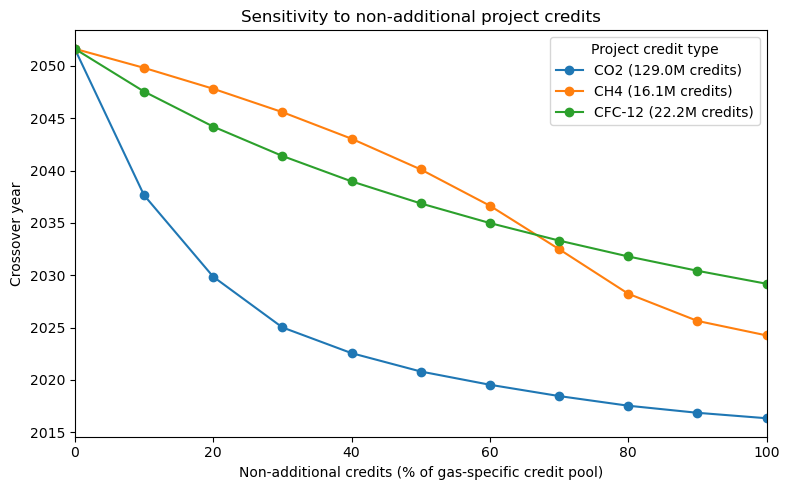

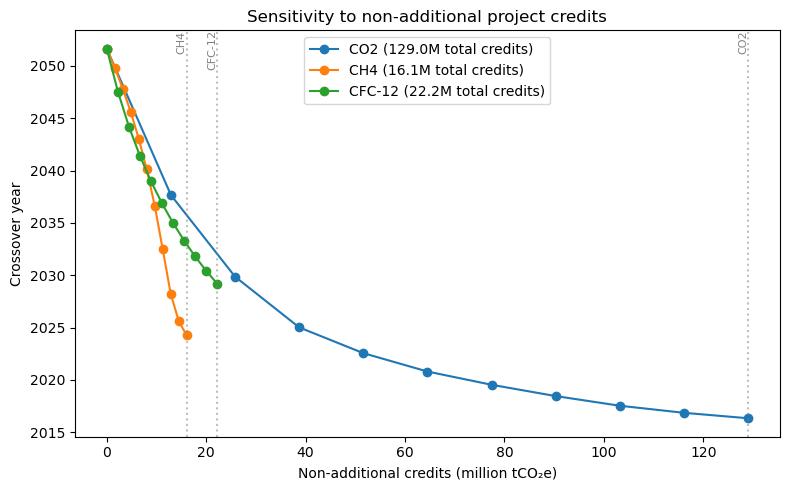

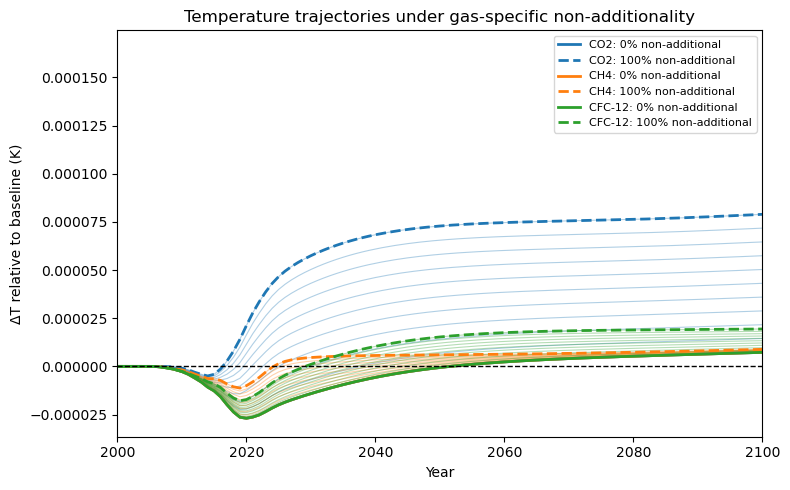

In [181]:
# In this test, we test how the crossover point is impacted by some proportion of either CO2, CH4, or CFC12 characterized as non-additional.
# For example, for non-additional CH4 credits, project CH4 fluxes are lowered but justified emissions remain the same.

from tqdm import tqdm

# use crediting period only to calculate issued credits
df_p_crediting = df_p[df_p["year"] <= 2025].copy()

credit_totals = {
    "CO2": -1 * df_p_crediting["co2_flux"].sum(),
    "CH4": -1 * (df_p_crediting["ch4_flux"] * df_p_crediting["year"].apply(gwp_ch4)).sum(),
    "CFC-12": -1 * (df_p_crediting["cfc-12_flux"] * gwp_cfc12).sum()}

nonadd_results = []
nonadd_trajectories = []

for gas, total_credits in tqdm(credit_totals.items(), desc="Gas"):
    credit_steps = np.linspace(0, total_credits, 11)

    for nonadd_credits in credit_steps:
        frac_nonadd = nonadd_credits / total_credits

        # use full project time series so 2110 re-emission is retained
        df_p_test = df_p.copy()

        # only reduce project benefits during the crediting period
        crediting_mask = df_p_test["year"] <= 2025

        if gas == "CO2":
            df_p_test.loc[crediting_mask, "co2_flux"] = (
                df_p_test.loc[crediting_mask, "co2_flux"] * (1 - frac_nonadd))
        elif gas == "CH4":
            df_p_test.loc[crediting_mask, "ch4_flux"] = (
                df_p_test.loc[crediting_mask, "ch4_flux"] * (1 - frac_nonadd))
        elif gas == "CFC-12":
            df_p_test.loc[crediting_mask, "cfc-12_flux"] = (
                df_p_test.loc[crediting_mask, "cfc-12_flux"] * (1 - frac_nonadd))

        years_test, temp_test = run_program_fair(df_p_test, df_e)
        crossover_year = find_crossover_year(years_test, temp_test)

        nonadd_trajectories.append({
            "gas": gas,
            "nonadd_credits": nonadd_credits,
            "frac_nonadd": frac_nonadd,
            "years": years_test,
            "temp": temp_test})

        nonadd_results.append({
            "gas": gas,
            "nonadd_credits": nonadd_credits,
            "frac_nonadd": frac_nonadd,
            "crossover_year": crossover_year})

nonadd_results = pd.DataFrame(nonadd_results)

print("Total CO2 credits:", credit_totals["CO2"])
print("Total CH4 credits:", credit_totals["CH4"])
print("Total CFC-12 credits:", credit_totals["CFC-12"])


#  --- plot crossover year vs percent non-additional credits  --- 

plt.figure(figsize=(8, 5))
ax = plt.gca()

for gas in ["CO2", "CH4", "CFC-12"]:
    plot_df = nonadd_results[nonadd_results["gas"] == gas].copy()
    plot_df["percent_nonadd"] = plot_df["frac_nonadd"] * 100

    ax.plot(
        plot_df["percent_nonadd"],
        plot_df["crossover_year"],
        marker="o",
        label=f"{gas} ({credit_totals[gas] / 1e6:.1f}M credits)"
    )

ax.set_xlabel("Non-additional credits (% of gas-specific credit pool)")
ax.set_ylabel("Crossover year")
ax.set_title("Sensitivity to non-additional project credits")
ax.set_xlim(0, 100)
ax.legend(title="Project credit type")
plt.tight_layout()
plt.show()


#  --- plot crossover year vs absolute non-additional credits  --- 

plt.figure(figsize=(8, 5))
ax = plt.gca()

for gas in ["CO2", "CH4", "CFC-12"]:
    plot_df = nonadd_results[nonadd_results["gas"] == gas]

    ax.plot(
        plot_df["nonadd_credits"] / 1e6,
        plot_df["crossover_year"],
        marker="o",
        label=f"{gas} ({credit_totals[gas] / 1e6:.1f}M total credits)")

for gas in ["CO2", "CH4", "CFC-12"]:
    ax.axvline(credit_totals[gas] / 1e6, linestyle=":", alpha=0.5, color="gray")
    ax.text(credit_totals[gas] / 1e6, ax.get_ylim()[1], gas, rotation=90, va="top", ha="right", fontsize=8, color="gray")

ax.set_xlabel("Non-additional credits (million tCO₂e)")
ax.set_ylabel("Crossover year")
ax.set_title("Sensitivity to non-additional project credits")
ax.legend()
plt.tight_layout()
plt.show()


#  ---  plot temperature trajectories for all non-additionality scenarios  --- 

colors = {
    "CO2": "tab:blue",
    "CH4": "tab:orange",
    "CFC-12": "tab:green"}

plt.figure(figsize=(8, 5))
ax = plt.gca()

for result in nonadd_trajectories:
    ax.plot(result["years"], result["temp"], color=colors[result["gas"]], linewidth=0.8, alpha=0.35)

for gas in ["CO2", "CH4", "CFC-12"]:
    gas_results = [r for r in nonadd_trajectories if r["gas"] == gas]

    zero_nonadd = min(gas_results, key=lambda x: x["frac_nonadd"])
    full_nonadd = max(gas_results, key=lambda x: x["frac_nonadd"])

    ax.plot(zero_nonadd["years"], zero_nonadd["temp"], color=colors[gas], linewidth=2, label=f"{gas}: 0% non-additional")

    ax.plot(full_nonadd["years"], full_nonadd["temp"], color=colors[gas], linewidth=2, linestyle="--", label=f"{gas}: 100% non-additional")

ax.axhline(0, linestyle="--", linewidth=1, color="k")
ax.set_xlim(2000, 2100)
ax.set_xlabel("Year")
ax.set_ylabel("ΔT relative to baseline (K)")
ax.set_title("Temperature trajectories under gas-specific non-additionality")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


The first two plots show that CO2 non-additionality has the largest effect when expressed as a percentage of each gas-specific credit pool, largely because CO2 accounts for more total credits in the program. When crossover timing is plotted against absolute CO2e credits, CH4 and CFC-12 non-additionality appear slightly more sensitive per credit.

However, these crossover sensitivities are partly shaped by the temperature trajectory of the full program, because each gas-specific perturbation is evaluated against the same combined project and justified-emissions baseline. It could be useful to run a complementary set of experiments that evaluates each gas separately, with gas-specific project fluxes and their corresponding CO2e justified emissions isolated from the rest of the program. This might be getting too in the weeds though...
